In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
train_data_dir = "/content/drive/MyDrive/Pivot/genai/data/10_pelobottle/"

Caption Settings ( trigger word = water bottle)

In [8]:
caption_extension = ".txt"

Training Settings

In [9]:
pretrained_model_name_or_path = "runwayml/stable-diffusion-v1-5"
resolution = "512,512"
train_batch_size = 1
max_train_epochs = 15
learning_rate = 1e-4
network_module = "networks.lora"
network_dim = 8

Set Output folder

In [10]:
output_dir = "/content/drive/MyDrive/Pivot/genai/output/10_pelobottle/"
output_name = "pelobottle_lora"

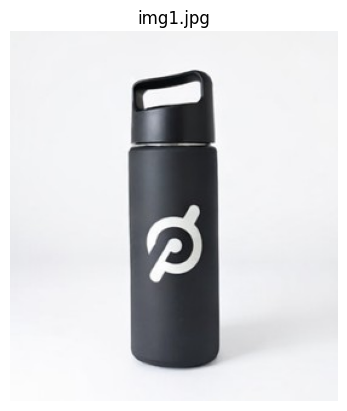

Caption: a photo of water bottle
----------------------------------------


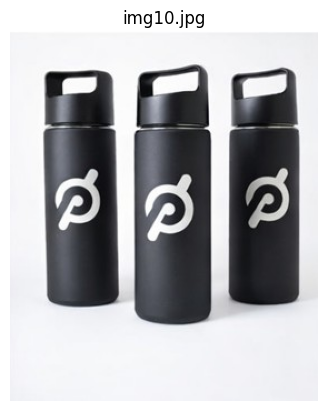

Caption: a photo of water bottle
----------------------------------------


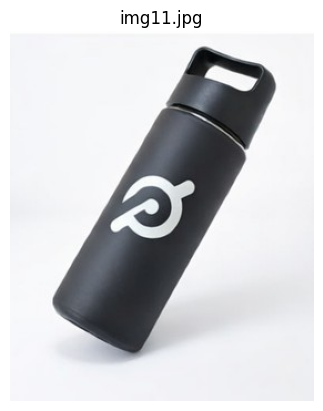

Caption: a photo of water bottle
----------------------------------------


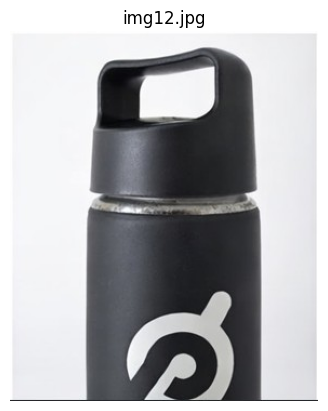

Caption: a photo of water bottle
----------------------------------------


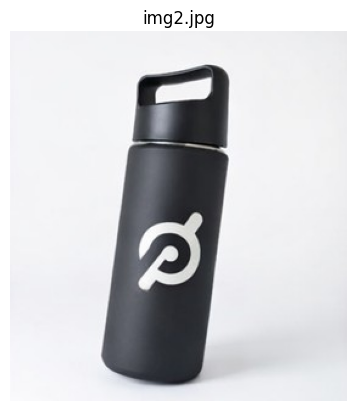

Caption: a photo of water bottle
----------------------------------------


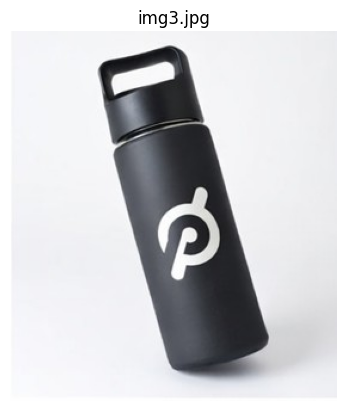

Caption: a photo of water bottle
----------------------------------------


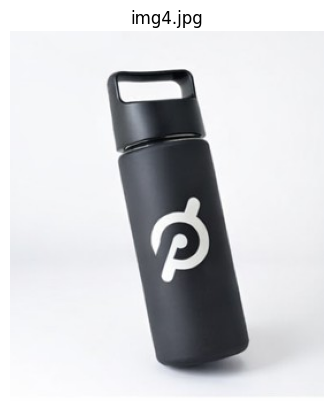

Caption: a photo of water bottle
----------------------------------------


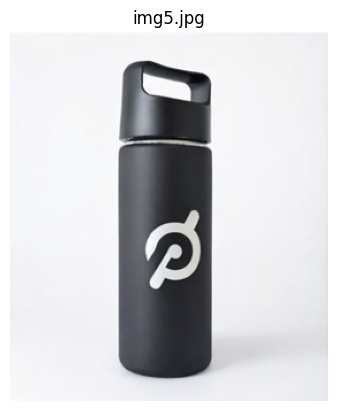

Caption: a photo of water bottle
----------------------------------------


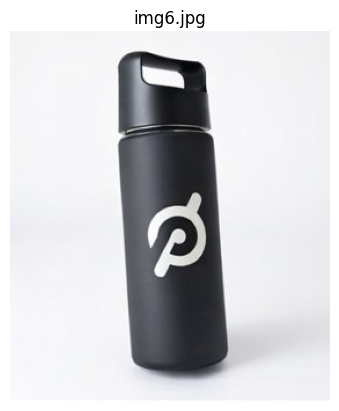

Caption: a photo of water bottle
----------------------------------------


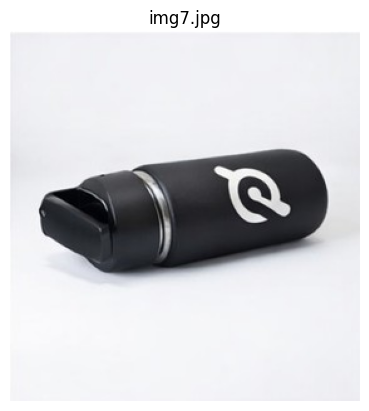

Caption: a photo of water bottle
----------------------------------------


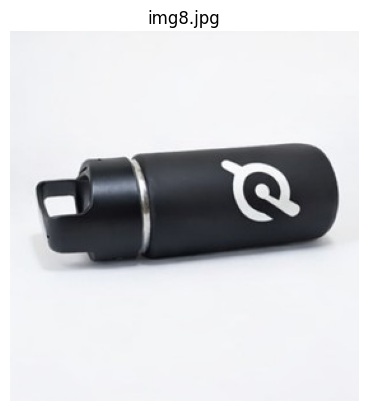

Caption: a photo of water bottle
----------------------------------------


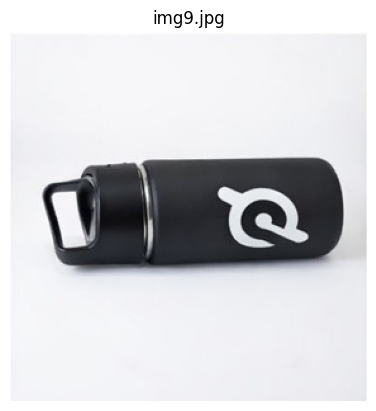

Caption: a photo of water bottle
----------------------------------------


In [11]:
import os
from PIL import Image
import matplotlib.pyplot as plt

data_path = "/content/drive/MyDrive/Pivot/genai/data/10_pelobottle/"

files = sorted(os.listdir(data_path))

for file in files:
    if file.endswith((".png", ".jpg", ".jpeg")):
        img_path = os.path.join(data_path, file)
        txt_path = os.path.splitext(img_path)[0] + ".txt"

        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(file)
        plt.axis('off')
        plt.show()

        if os.path.exists(txt_path):
            with open(txt_path, "r") as f:
                caption = f.read()
            print("Caption:", caption)
        else:
            print(" Missing caption for", file)

        print("-" * 40)

In [12]:
data_dir = "/content/drive/MyDrive/Pivot/genai/data/10_pelobottle/"
output_dir = "/content/drive/MyDrive/Pivot/genai/output"

os.makedirs(output_dir, exist_ok=True)

In [13]:
import torch
print(torch.cuda.is_available())

True


TRAINING CELL (KOHYA)

In [2]:
!git clone https://github.com/kohya-ss/sd-scripts.git
%cd sd-scripts
!pip install -r requirements.txt

fatal: destination path 'sd-scripts' already exists and is not an empty directory.
/content/sd-scripts
Obtaining file:///content/sd-scripts (from -r requirements.txt (line 49))
  Preparing metadata (setup.py) ... done
  Attempting uninstall: library
    Found existing installation: library 0.0.0
    Uninstalling library-0.0.0:
      Successfully uninstalled library-0.0.0
  Running setup.py develop for library


In [14]:
!accelerate launch train_network.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --train_data_dir="/content/drive/MyDrive/Pivot/genai/data/" \
  --output_dir="/content/drive/MyDrive/Pivot/genai/output/10_pelobottle/" \
  --resolution=512,512 \
  --network_module=networks.lora \
  --network_dim=8 \
  --train_batch_size=1 \
  --max_train_epochs=15 \
  --learning_rate=1e-4 \
  --caption_extension=".txt" \
  --save_model_as=safetensors \
  --output_name="pelobottle_lora" \
  --mixed_precision="fp16" \
  --cache_latents \
  --optimizer_type="AdamW8bit" \
  --save_every_n_epochs=5 \
  --logging_dir="/content/drive/MyDrive/Pivot/genai/logs"

## Data Structure Setup

Kohya sd-scripts requires `train_data_dir` to be the **parent** of a `{repeats}_{concept}/` folder.
The correct structure is:
```
data/
  10_pelobottle/    ← {10 repeats}_{concept name}
    img1.jpg
    img1.txt
    ...
```
Run the cell below **once** to verify your Google Drive structure is correct.

In [ ]:
import os

# Correct paths for Kohya DreamBooth training
parent_data_dir = "/content/drive/MyDrive/Pivot/genai/data/"
concept_dir     = "/content/drive/MyDrive/Pivot/genai/data/10_pelobottle/"

# Verify structure
if not os.path.exists(concept_dir):
    print(f"ERROR: concept folder not found: {concept_dir}")
    print("Create the folder and place images + .txt captions inside it.")
else:
    images = [f for f in os.listdir(concept_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    txts   = [f for f in os.listdir(concept_dir) if f.endswith('.txt')]
    print(f"Concept folder OK: {concept_dir}")
    print(f"  Found {len(images)} images and {len(txts)} captions")
    print(f"train_data_dir should be: {parent_data_dir}")
    # Show a sample caption
    if txts:
        sample = os.path.join(concept_dir, sorted(txts)[0])
        with open(sample) as fh:
            print(f"  Sample caption ({sorted(txts)[0]}): '{fh.read().strip()}'")


---
## Inference: Product-in-Context Generator

After training, we load the fine-tuned LoRA weights onto the base Stable Diffusion model and generate the **specific Pelo water bottle** placed into different **advertising scenes**.

The trigger phrase `a photo of water bottle` activates the learned product appearance.

In [ ]:
# Install / verify inference dependencies
!pip install diffusers transformers accelerate safetensors -q


In [ ]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import os

LORA_PATH   = "/content/drive/MyDrive/Pivot/genai/output/10_pelobottle/pelobottle_lora.safetensors"
BASE_MODEL  = "runwayml/stable-diffusion-v1-5"
SEED        = 42
STEPS       = 30
GUIDANCE    = 7.5

# Advertising scene prompts — trigger word is 'water bottle'
SCENES = [
    ("Mountain Adventure",
     "a photo of water bottle on a rocky mountain trail at golden hour, "
     "dramatic cinematic lighting, outdoor adventure advertising"),
    ("Beach Lifestyle",
     "a photo of water bottle at a tropical beach with turquoise ocean waves, "
     "summer vibes, lifestyle product photography"),
    ("Gym & Fitness",
     "a photo of water bottle in a modern gym with weights and equipment in the background, "
     "fitness motivation, bright clean lighting"),
    ("Forest Wellness",
     "a photo of water bottle in a misty pine forest with soft morning sunlight, "
     "nature wellness, serene atmosphere, editorial photo"),
]

print(f"Loaded {len(SCENES)} advertising scenes.")
for name, prompt in SCENES:
    print(f"  [{name}]")


In [ ]:
# ── BEFORE: Base Stable Diffusion (no LoRA — generic bottle) ──────────────
print("Generating BEFORE images (base SD, no fine-tuning)...")

base_pipe = StableDiffusionPipeline.from_pretrained(
    BASE_MODEL, torch_dtype=torch.float16, safety_checker=None
).to("cuda")
base_pipe.set_progress_bar_config(disable=True)

before_images = []
for name, prompt in SCENES:
    gen = torch.Generator("cuda").manual_seed(SEED)
    img = base_pipe(
        prompt, num_inference_steps=STEPS, guidance_scale=GUIDANCE, generator=gen
    ).images[0]
    before_images.append((name, img))
    print(f"  Generated: {name}")

del base_pipe
torch.cuda.empty_cache()
print("Done — BEFORE images ready.")


In [ ]:
# ── AFTER: LoRA Fine-tuned (specific Pelo bottle in advertising contexts) ──
print("Generating AFTER images (LoRA-tuned Pelo bottle)...")

lora_pipe = StableDiffusionPipeline.from_pretrained(
    BASE_MODEL, torch_dtype=torch.float16, safety_checker=None
).to("cuda")
lora_pipe.set_progress_bar_config(disable=True)

# Load the trained LoRA weights
lora_pipe.load_lora_weights(LORA_PATH)
print(f"LoRA loaded from: {LORA_PATH}")

after_images = []
for name, prompt in SCENES:
    gen = torch.Generator("cuda").manual_seed(SEED)
    img = lora_pipe(
        prompt, num_inference_steps=STEPS, guidance_scale=GUIDANCE, generator=gen
    ).images[0]
    after_images.append((name, img))
    print(f"  Generated: {name}")

del lora_pipe
torch.cuda.empty_cache()
print("Done — AFTER images ready.")


In [ ]:
# ── Side-by-side Before / After comparison grid ────────────────────────────
n = len(SCENES)
fig, axes = plt.subplots(n, 2, figsize=(10, 4.5 * n))

for i, ((name, before_img), (_, after_img)) in enumerate(zip(before_images, after_images)):
    axes[i, 0].imshow(before_img)
    axes[i, 0].set_title(f"BEFORE — Base SD\n(generic bottle, no fine-tuning)",
                          fontsize=10, color="#c0392b", fontweight="bold")
    axes[i, 0].set_xlabel(f"Scene: {name}", fontsize=9)
    axes[i, 0].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    axes[i, 1].imshow(after_img)
    axes[i, 1].set_title(f"AFTER — LoRA Fine-tuned\n(Pelo bottle in context)",
                          fontsize=10, color="#27ae60", fontweight="bold")
    axes[i, 1].set_xlabel(f"Scene: {name}", fontsize=9)
    axes[i, 1].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

fig.suptitle(
    "Product-in-Context Generator\nBefore vs After LoRA Fine-tuning on Pelo Water Bottle",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()

out_dir = "/content/drive/MyDrive/Pivot/genai/output"
os.makedirs(out_dir, exist_ok=True)
save_path = os.path.join(out_dir, "before_after_comparison.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Comparison grid saved to: {save_path}")


### Extra: Generate More Advertising Variants

Use the cell below to generate the product in any custom scene — just edit the `custom_prompts` list.

In [ ]:
# Reload LoRA pipe for custom generation
lora_pipe = StableDiffusionPipeline.from_pretrained(
    BASE_MODEL, torch_dtype=torch.float16, safety_checker=None
).to("cuda")
lora_pipe.set_progress_bar_config(disable=True)
lora_pipe.load_lora_weights(LORA_PATH)

# ── Edit these prompts to generate any advertising scene ──────────────────
custom_prompts = [
    "a photo of water bottle on a wooden desk with a laptop and coffee cup, "
    "work from home lifestyle, warm natural lighting",

    "a photo of water bottle submerged in ice with water droplets splashing, "
    "cold refreshing product shot, studio lighting, dark background",

    "a photo of water bottle next to fresh fruits and vegetables on a marble counter, "
    "healthy living, clean minimalist styling",
]
# ──────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, len(custom_prompts), figsize=(6 * len(custom_prompts), 6))
if len(custom_prompts) == 1:
    axes = [axes]

for ax, prompt in zip(axes, custom_prompts):
    gen = torch.Generator("cuda").manual_seed(SEED)
    img = lora_pipe(prompt, num_inference_steps=STEPS, guidance_scale=GUIDANCE, generator=gen).images[0]
    ax.imshow(img)
    # Wrap long prompt for title
    short = prompt[:80] + "..." if len(prompt) > 80 else prompt
    ax.set_title(short, fontsize=8, wrap=True)
    ax.axis("off")

plt.suptitle("Custom Advertising Variants (LoRA)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

del lora_pipe
torch.cuda.empty_cache()


---
## Reflection: Risks, Ethics & Evaluation

### What the Model Learned
After LoRA fine-tuning on **12 images** of the Pelo water bottle with the caption `"a photo of water bottle"`, the model learned to associate that trigger phrase with the specific visual identity of the Pelo bottle — its shape, color, texture, and label design. At inference time, appending any background description to the trigger phrase places the **learned product** into any scene we can describe in text, enabling zero-shot advertising content creation.

---

### Evaluation Challenges
| Challenge | Detail |
|-----------|--------|
| **No quantitative ground truth** | Visual fidelity and brand consistency are judged by human review, not automated metrics. FID scores compare distributions but not specific product accuracy. |
| **Small dataset overfitting** | 12 images is minimal; the model may reproduce training-set backgrounds rather than learning pure shape/texture. |
| **Prompt sensitivity** | Minor wording changes ("bottle" vs "water bottle") can collapse to the base model's prior. Robust prompt engineering is needed. |
| **Trigger word collision** | "water bottle" is a common concept in the base model — disentangling the specific product from the generic concept is the core learning challenge. |

---

### Ethical Risks
1. **Misleading advertising** — AI-generated scenes may depict unrealistic product performance or settings, deceiving consumers without costly photoshoots.
2. **Brand impersonation** — Malicious actors could fine-tune on a competitor's product to generate fake promotional material.
3. **Greenwashing enablement** — Placing any product in pristine nature scenes is trivially easy, potentially enabling environmental-responsibility deception.
4. **Copyright & consent** — The base SD model was trained on scraped internet images; generated outputs may reflect unattributed artistic styles.
5. **Labor displacement** — Automating product photography could displace photographers and creative directors.

### Mitigations
- Watermark all AI-generated images with metadata (C2PA standard)
- Mandate disclosure labels in advertising materials
- Restrict fine-tuned model weights to authorized brand use
- Human creative review before any generated asset goes public
- Evaluate outputs against brand style guides, not just aesthetic quality
